# Scattering time downturn validation - CHIME/FRB Selection Function 

### Author: Kyle McGregor (McGill University)

In [2]:
import json
import math
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, kstwobign
from scipy.interpolate import interp1d
from tqdm import tqdm

import chimefrb_selection as cfsf

### Load the catalog

dict_keys(['tns_name', 'previous_name', 'repeater_name', 'event_id', 'sub_num', 'ra', 'ra_err', 'dec', 'dec_err', 'ra_dec_notes', 'gl', 'gb', 'exp_up', 'exp_up_err', 'exp_low', 'exp_low_err', 'exp_notes', 'bonsai_snr', 'bonsai_dm', 'low_ft_68', 'up_ft_68', 'low_ft_95', 'up_ft_95', 'snr_fitb', 'dm_fitb', 'dm_fitb_err', 'dm_exc_ne2001', 'dm_exc_ymw16', 'bc_width', 'scat_time', 'scat_time_err', 'flux', 'flux_err', 'fluence', 'fluence_err', 'fluence_notes', 'fluence_win_extended', 'mjd_400', 'mjd_400_err', 'mjd_inf', 'mjd_inf_err', 'width_fitb', 'width_fitb_err', 'sp_idx', 'sp_idx_err', 'sp_run', 'sp_run_err', 'high_freq', 'low_freq', 'peak_freq', 'chi_sq', 'dof', 'flag_frac', 'notes_fitb', 'intrachan_flag', 'excluded_flag', 'sidelobe_flag', 'citizen_science_flag', 'catalog1_flag', 'catalog1_param_flag'])
Catalog contains 5040 entries


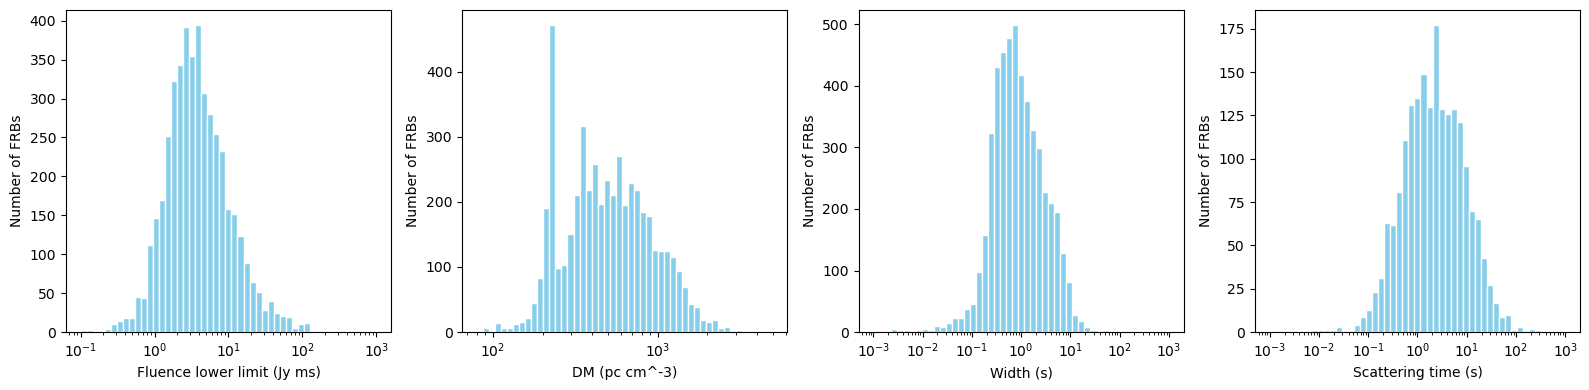

In [3]:
with open("/data/user-data/ssiegel/catalog2/table/20251121/chimefrbcat2.json") as fh:
    catalog_raw = json.load(fh)
    print(catalog_raw[0].keys())

cat_fluence_LL = np.array([entry["fluence"] for entry in catalog_raw])
cat_dm = np.array([entry["dm_fitb"] for entry in catalog_raw])
cat_width = np.array([entry["width_fitb"] for entry in catalog_raw])
cat_scat = np.array([entry["scat_time"] for entry in catalog_raw])

cat_width_ms = cat_width * 1e3
cat_scat_600_ms = cat_scat * (600/400)**-4 * 1e3

print(f"Catalog contains {len(catalog_raw)} entries")

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].hist(cat_fluence_LL, bins=np.geomspace(0.1, 1000, 50), color='skyblue', edgecolor='white')
axs[1].hist(cat_dm, bins=np.geomspace(80, 5000, 50), color='skyblue', edgecolor='white')
axs[2].hist(cat_width_ms, bins=np.geomspace(1e-3, 1e3, 50), color='skyblue', edgecolor='white')
axs[3].hist(cat_scat_600_ms, bins=np.geomspace(1e-3, 1e3, 50), color='skyblue', edgecolor='white') 
  
for ax in axs:
    ax.set_ylabel("Number of FRBs")
    ax.set_yscale("linear")
    ax.set_xscale("log")
axs[0].set_xlabel("Fluence lower limit (Jy ms)")
axs[1].set_xlabel("DM (pc cm^-3)")
axs[2].set_xlabel("Width (s)")
axs[3].set_xlabel("Scattering time (s)")
plt.tight_layout()

### Instantiate the fiducial model and a scattering time model
We set the model as a half-lognormal half-semilog distribution. The left side of this distribution is lognormal up to the peak at $\mu_{\tau}$ and the right side is semi-log with some variable slope $\beta$. 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

class FiducialModel:
    """
    Fiducial forward-model sampler for (Fluence, Width, DM).

    Matches the script conventions:
      - fluence: truncated power-law on [FMIN_JYMS, FMAX_JYMS] (Jy ms)
      - dm:      truncated lognormal on [DM_LO, DM_HI] (pc/cc)
      - width:   truncated lognormal on [W_LO_S, W_HI_S] (seconds)

    Usage
    -----
    fid = FiducialFWDM()
    F_jyms, W_s, DM = fid.rvs(10000, random_state=0)
    """

    FMIN_JYMS, FMAX_JYMS = 0.1, 10000.0
    W_LO_S, W_HI_S = 1e-4, 0.2
    DM_LO, DM_HI = 100.0, 5000.0

    ALPHA_FLUENCE = -1.203108427072943

    DM_SHAPE = 0.6076516890745998
    DM_SCALE = 534.4727066208081

    WIDTH_SHAPE = 1.1012853240184415
    WIDTH_SCALE = 0.0007389903164298552

    # -------------------------------------------------------------

    def __init__(
        self,
        alpha_fluence: float = None,
        fmin_jyms: float = None,
        fmax_jyms: float = None,
        dm_shape: float = None,
        dm_scale: float = None,
        dm_lo: float = None,
        dm_hi: float = None,
        width_shape: float = None,
        width_scale: float = None,
        w_lo_s: float = None,
        w_hi_s: float = None,
    ):
        # allow overrides, defaulting to script constants
        self.alpha_fluence = float(self.ALPHA_FLUENCE if alpha_fluence is None else alpha_fluence)
        self.fmin_jyms = float(self.FMIN_JYMS if fmin_jyms is None else fmin_jyms)
        self.fmax_jyms = float(self.FMAX_JYMS if fmax_jyms is None else fmax_jyms)

        self.dm_shape = float(self.DM_SHAPE if dm_shape is None else dm_shape)
        self.dm_scale = float(self.DM_SCALE if dm_scale is None else dm_scale)
        self.dm_lo = float(self.DM_LO if dm_lo is None else dm_lo)
        self.dm_hi = float(self.DM_HI if dm_hi is None else dm_hi)

        self.width_shape = float(self.WIDTH_SHAPE if width_shape is None else width_shape)
        self.width_scale = float(self.WIDTH_SCALE if width_scale is None else width_scale)
        self.w_lo_s = float(self.W_LO_S if w_lo_s is None else w_lo_s)
        self.w_hi_s = float(self.W_HI_S if w_hi_s is None else w_hi_s)

        self._validate()

    def _validate(self):
        if not np.isfinite(self.alpha_fluence):
            raise ValueError("alpha_fluence must be finite.")
        if not (self.fmin_jyms > 0 and self.fmax_jyms > self.fmin_jyms):
            raise ValueError("Bad fluence bounds.")

        if not (self.dm_shape > 0 and self.dm_scale > 0):
            raise ValueError("dm_shape/dm_scale must be > 0.")
        if not (self.dm_lo > 0 and self.dm_hi > self.dm_lo):
            raise ValueError("Bad DM bounds.")

        if not (self.width_shape > 0 and self.width_scale > 0):
            raise ValueError("width_shape/width_scale must be > 0.")
        if not (self.w_lo_s > 0 and self.w_hi_s > self.w_lo_s):
            raise ValueError("Bad width bounds.")

    @staticmethod
    def _draw_powerlaw_trunc(N: int, alpha_tail: float, xmin: float, xmax: float, rng):
        """
        Draw from p(x) ∝ x^(alpha_tail - 1) on [xmin, xmax]
        using the same inversion used in your script:
            x = xmin * u^(1/alpha_tail), with u ~ Uniform(s_max, 1)
            s_max = (xmax/xmin)^alpha_tail
        """
        if N <= 0:
            return np.empty(0, dtype=float)
        s_max = (xmax / xmin) ** alpha_tail
        u = rng.uniform(s_max, 1.0, size=N)
        return xmin * (u ** (1.0 / alpha_tail))

    @staticmethod
    def _sample_trunc_lognorm_icdf(N: int, sigma_ln: float, scale: float, lo: float, hi: float, rng):
        if N <= 0:
            return np.empty(0, dtype=float)
        dist = lognorm(s=sigma_ln, scale=scale)
        c_lo, c_hi = dist.cdf(lo), dist.cdf(hi)
        if not (np.isfinite(c_lo) and np.isfinite(c_hi) and c_hi > c_lo):
            return np.full(N, lo, dtype=float)
        u = rng.uniform(c_lo, c_hi, size=N)
        return np.clip(dist.ppf(u), lo, hi)

    def rvs(self, size: int, random_state=None):
        """
        Returns:
          fluence_jyms : (N,) in Jy ms
          width_s      : (N,) in seconds
          dm           : (N,) in pc/cc
        """
        N = int(size)
        if N < 0:
            raise ValueError("size must be >= 0.")
        rng = np.random.default_rng(random_state)

        fluence_jyms = self._draw_powerlaw_trunc(
            N, alpha_tail=self.alpha_fluence, xmin=self.fmin_jyms, xmax=self.fmax_jyms, rng=rng
        )
        dm = self._sample_trunc_lognorm_icdf(
            N, sigma_ln=self.dm_shape, scale=self.dm_scale, lo=self.dm_lo, hi=self.dm_hi, rng=rng
        )
        width_s = self._sample_trunc_lognorm_icdf(
            N, sigma_ln=self.width_shape, scale=self.width_scale, lo=self.w_lo_s, hi=self.w_hi_s, rng=rng
        )
        return fluence_jyms, width_s, dm

class LognormalSemiLogTail:
    """
    Half lognormal (tau <= tau0) + straight line on (log-x, linear-y) tail (tau >= tau0).

    Tail form for tau >= tau0:
        p(tau) = f0 + m * log10(tau/tau0)
    where f0 = lognormal_pdf(tau0) so the pdf is continuous at tau0.

    Params:
      mu, sigma : lognormal parameters (scipy lognorm with s=sigma, scale=exp(mu))
      m         : tail slope in "pdf units per dex" on a log-x / linear-y plot

    This samples at a REFERENCE FREQUENCY -> 600 MHz
    and times are in SECONDS 
    """

    TAU_MIN_MS = 1e-4
    TAU_MAX_MS = 100e-3 

    def __init__(self, beta: float = -30.0):
        self.mu = (0.0131)
        self.sigma = 1.94
        self.beta = float(beta)
        if not (np.isfinite(self.mu) and np.isfinite(self.sigma) and np.isfinite(self.beta)):
            raise ValueError("mu, sigma, m must be finite.")
        if self.sigma <= 0:
            raise ValueError("sigma must be > 0.")
        if not (self.TAU_MIN_MS > 0 and self.TAU_MAX_MS > self.TAU_MIN_MS):
            raise RuntimeError("Bad tau bounds.")

    @property
    def tau0(self) -> float:
        return float(np.exp(self.mu - self.sigma**2))  # lognormal mode

    @property
    def _ln(self):
        return lognorm(s=self.sigma, scale=np.exp(self.mu))

    def _pdf_unnorm(self, tau: np.ndarray) -> np.ndarray:
        tau = np.asarray(tau, dtype=float)
        out = np.zeros_like(tau)

        a, b = self.TAU_MIN_MS, self.TAU_MAX_MS
        ok = np.isfinite(tau) & (tau >= a) & (tau <= b)
        if not np.any(ok):
            return out

        t = tau[ok]
        t0 = self.tau0
        f0 = float(self._ln.pdf(t0))

        left = t <= t0
        right = ~left

        p = np.zeros_like(t)
        if np.any(left):
            p[left] = self._ln.pdf(t[left])
        if np.any(right):
            p[right] = f0 + self.beta * np.log10(t[right] / t0)

        out[ok] = np.maximum(p, 0.0)  # guard against tiny negatives if m is aggressive
        return out

    def _Z(self, ngrid: int = 8192) -> float:
        # numeric normalization (trapz) on log grid
        grid = np.geomspace(self.TAU_MIN_MS, self.TAU_MAX_MS, int(ngrid))
        z = np.trapz(self._pdf_unnorm(grid), grid)
        if not (np.isfinite(z) and z > 0):
            raise RuntimeError("Normalization failed; check mu/sigma/m.")
        return float(z)

    def pdf(self, tau, ngrid_Z: int = 8192):
        return self._pdf_unnorm(tau) / self._Z(ngrid=ngrid_Z)

    def rvs(self, size=1, random_state=None, ngrid_cdf: int = 8192):
        """
        Inverse-CDF sampling via a tabulated CDF on a log-spaced grid.
        """
        n = int(size)
        if n < 0:
            raise ValueError("size must be >= 0.")
        rng = np.random.default_rng(random_state)

        grid = np.geomspace(self.TAU_MIN_MS, self.TAU_MAX_MS, int(ngrid_cdf))
        p = self._pdf_unnorm(grid) / self._Z(ngrid=ngrid_cdf)
        cdf = np.zeros_like(grid)
        cdf[1:] = np.cumsum(0.5 * (p[1:] + p[:-1]) * (grid[1:] - grid[:-1]))
        cdf /= cdf[-1]
        cdf[0], cdf[-1] = 0.0, 1.0

        u = rng.uniform(0.0, 1.0, size=n)
        x = np.interp(u, cdf, grid)
        return np.clip(x, self.TAU_MIN_MS, self.TAU_MAX_MS)

    def plot_pdf(self, ax=None, ngrid=2000, show_tau0=True, label="pdf"):
        if ax is None:
            _, ax = plt.subplots(figsize=(6, 4))

        grid = np.geomspace(self.TAU_MIN_MS, self.TAU_MAX_MS, int(ngrid))
        ax.plot(grid, self.pdf(grid), label=label)

        ax.set_xscale("log")
        ax.set_xlabel(r"$\tau$ (s)")
        ax.set_ylabel(r"$p(\tau)$")

        if show_tau0:
            ax.axvline(self.tau0, ls="--", lw=1.2, label=r"$\tau_0$")

        return ax

Let's plot the model with different betas

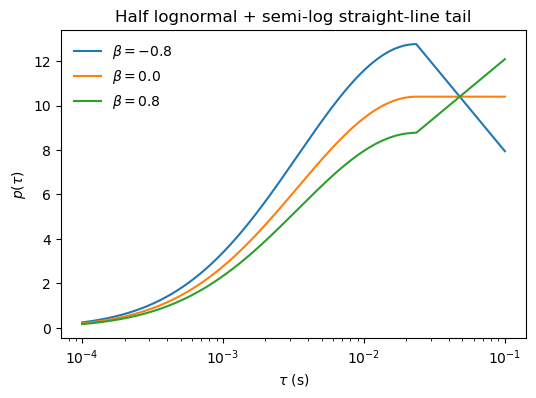

tau0: 0.02350598992230945 median: 0.03017853620183178


Text(0, 0.5, 'Density')

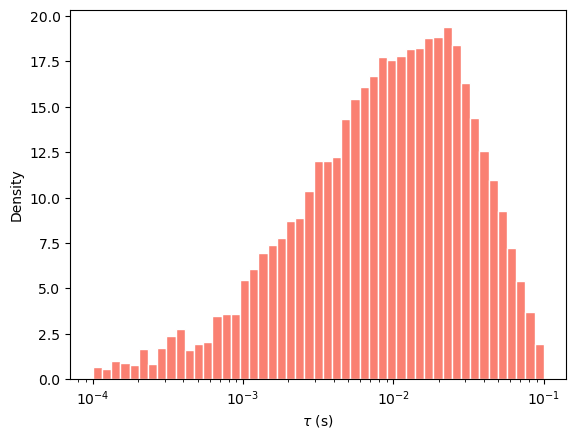

In [5]:
betas = [-0.8, 0.0, 0.8]

fig, ax = plt.subplots(figsize=(6, 4))

for beta in betas:
    model = LognormalSemiLogTail(beta=beta)
    model.plot_pdf(ax=ax, label=fr"$\beta = {beta}$", show_tau0=False)

ax.set_xscale("log")  # safe even if already set
ax.set_title("Half lognormal + semi-log straight-line tail")
ax.legend(frameon=False)

plt.show()

model = LognormalSemiLogTail(beta=-2)
s = model.rvs(100000, random_state=0)
print("tau0:", model.tau0, "median:", np.median(s))
plt.hist(s, bins=np.geomspace(model.TAU_MIN_MS, model.TAU_MAX_MS, 50), color='salmon', edgecolor='white', density=True)
plt.xscale("log")
plt.xlabel(r"$\tau$ (s)")
plt.ylabel("Density")

### Load the selection function

In [6]:
sf = cfsf.SelectionFunction(
        predictor_names=["fluence", "scattering_time", "width", "dm"],
        degree=4,
        snr_cut=12,
        exclude_sidelobes=True,
        sidelobe_cut=5.0,
    )

# Vectorized evaluation
burst_properties = {'fluence_jy_ms':np.random.uniform(1,10,10000),
                    'tau_1_ghz_ms':np.random.uniform(1e-3,1e-1,10000),
                    'pulse_width_ms':np.random.uniform(0.5,5.0,10000),
                    'dm':np.random.uniform(100,1000,10000)}

p_vec, p_vec_std = sf.calculate_selection_probability(burst_properties, return_std=True)
print(p_vec[:10], p_vec_std[:10])

/home/kmcgregor/chimefrb-selection/chimefrb_selection/selection.py:133: RuntimeWarning: 4D selection functions are not reweighted; forcing reweighted=False
  warnings.warn(


[0.35211618 0.3065038  0.34807302 0.03869289 0.35332581 0.1715532
 0.25595676 0.25853704 0.09521577 0.27459   ] [0.00552882 0.00285437 0.00830526 0.00117291 0.00688649 0.00625463
 0.00379754 0.00466393 0.00338276 0.00717812]


### Monte carlo simulate over the fiducial model while varying $\beta$ 
Calculate a goodness of fit statistic for each model 

Text(0, 0.5, 'Width (ms)')

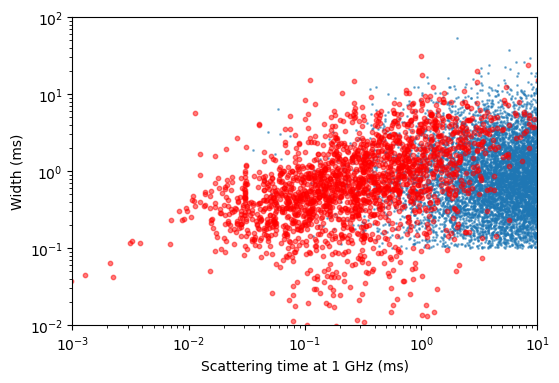

In [7]:
fid = FiducialModel()
N = 10_000
F_jyms, W_s, DM = fid.rvs(N)
W_ms = W_s * 1e3

model = LognormalSemiLogTail(beta=-1)
tau_s_600 = model.rvs(10000, random_state=0)
tau_ms_1000 = tau_s_600 * (1000/600)**-4 * 1e3

plt.figure(figsize=(6, 4))
plt.scatter(tau_ms_1000, W_ms, alpha=0.5, s=1)
plt.scatter(cat_scat_600_ms * (1000/600)**-4 , cat_width_ms, alpha=0.5, s=10, color='red', label='Catalog')
plt.xscale("log")
plt.yscale("log")
plt.xlim(1e-3, 1e1)
plt.ylim(1e-2, 1e2)
plt.xlabel("Scattering time at 1 GHz (ms)")
plt.ylabel("Width (ms)")

100%|██████████| 500000/500000 [17:27<00:00, 477.25it/s]


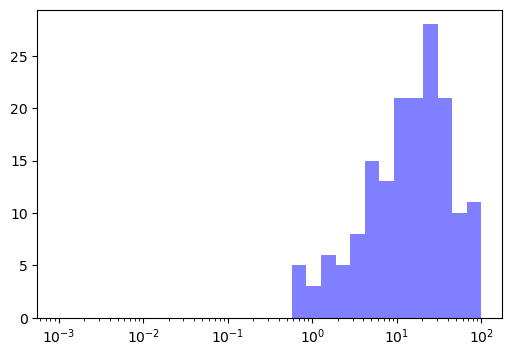

In [17]:
fid = FiducialModel()
N = 500_000
F_jyms, W_s, DM = fid.rvs(N)
W_ms = W_s * 1e3

model = LognormalSemiLogTail(beta=-1)
tau_s_600 = model.rvs(N , random_state=0)
tau_ms_1000 = tau_s_600 * (1000/600)**-4 * 1e3

# Vectorized evaluation
burst_properties = {'fluence_jy_ms':F_jyms,
                    'tau_1_ghz_ms':tau_ms_1000,
                    'pulse_width_ms':W_ms,
                    'dm':DM}

p_vec = []
for i in tqdm(range(N)):
    try:
        p = sf.calculate_selection_probability({k: burst_properties[k][i] for k in burst_properties})
        p_vec.append(p)
    except Exception as e:
        p_vec.append(0.0)

# bernoulli scattering times
p_vec = np.array(p_vec)
observed_mask = p_vec > np.random.uniform(0, 1, size=N)

### Plot the reweighted distribution of scattering times

plt.figure(figsize=(6, 4))
plt.hist(1e3*np.array(tau_s_600)[observed_mask], bins=np.geomspace(1e-3, 1e2, 30), alpha=0.5, color='blue', label='Reweighted')
plt.xscale("log")

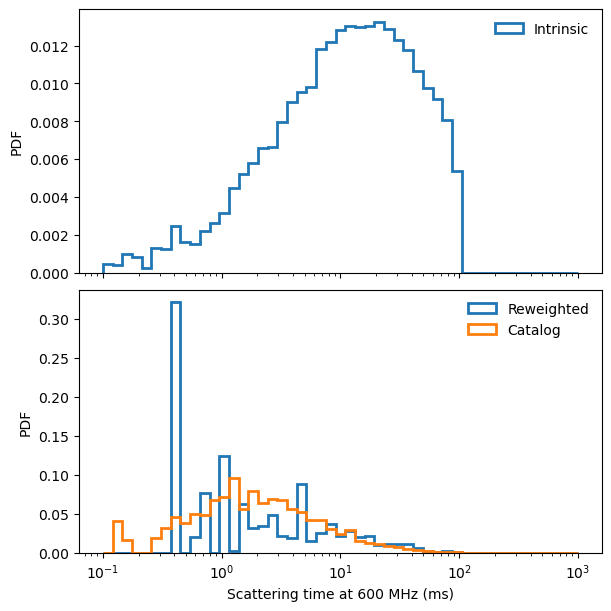

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- common bins / units (ms, log-spaced) ---
bins = np.geomspace(1e-1, 1e3, 50)  # ms
tau_ms_600 = np.asarray(tau_s_600) * 1e3
cat_scat_ms = np.asarray(cat_scat) * 1e3

# masks
m_intr = np.isfinite(tau_ms_600) & (tau_ms_600 > 0) & np.isfinite(p_vec)
m_cat  = np.isfinite(cat_scat_ms) & (cat_scat_ms > 0)

# --- 2-panel figure: intrinsic (top), reweighted+catalog (bottom), all as PDFs ---
fig, axes = plt.subplots(
    2, 1, figsize=(6, 6), sharex=True,
    constrained_layout=True
)

# Top: intrinsic PDF
ax = axes[0]
ax.hist(
    tau_ms_600[m_intr],
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    label="Intrinsic",
)
ax.set_xscale("log")
ax.set_ylabel("PDF")
ax.legend(frameon=False)

# Bottom: reweighted PDF + catalog PDF
ax = axes[1]
ax.hist(
    tau_ms_600[m_intr],
    bins=bins,
    density=True,
    weights=p_vec[m_intr],  # matplotlib handles weighted density normalization
    histtype="step",
    linewidth=2,
    label="Reweighted",
)
ax.hist(
    cat_scat_ms[m_cat],
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    label="Catalog",
)
ax.set_xscale("log")
ax.set_xlabel("Scattering time at 600 MHz (ms)")
ax.set_ylabel("PDF")
ax.legend(frameon=False)

plt.show()